<a href="https://colab.research.google.com/github/varunchach/CNN/blob/main/CNN_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolution Operation

### Subtask:
Explain the concept of convolution in CNNs, including kernels/filters and strides. Demonstrate a 2D convolution operation on a sample input matrix, displaying the input and the resulting output matrix.


### Convolution Operation: Understanding Kernels, Strides, and Feature Extraction

#### What is Convolution?

In the context of Convolutional Neural Networks (CNNs), convolution is a mathematical operation that applies a filter (also known as a kernel) to an input, such as an image, to produce a feature map. This process is fundamental to how CNNs detect features like edges, textures, and patterns.

#### Kernels (Filters)

A **kernel** (or **filter**) is a small matrix of numbers that slides over the input data. Each number in the kernel represents a weight. During the convolution operation, the kernel is superimposed over a segment of the input, and element-wise multiplication is performed between the kernel's weights and the corresponding input values. These products are then summed up to produce a single output value in the feature map. Different kernels are designed to detect different types of features (e.g., a kernel might highlight horizontal edges, while another might highlight vertical edges).

#### Strides

**Stride** refers to the number of pixels by which the kernel shifts over the input image or feature map. If the stride is 1, the kernel moves one pixel at a time. If the stride is 2, it moves two pixels at a time, effectively skipping some pixels and reducing the spatial dimensions of the output feature map. A larger stride results in a smaller output feature map, which can reduce computational cost and help in down-sampling the input.

#### Purpose in CNNs

The primary purpose of convolution in CNNs is **feature extraction**. By applying various kernels, the network can automatically learn to identify hierarchical patterns and features from the input data. Early layers might detect simple features like edges and corners, while deeper layers can combine these simpler features to detect more complex structures like shapes or objects. This hierarchical feature learning is a key reason for the success of CNNs in tasks like image recognition and object detection.

In [1]:
import numpy as np
from scipy.signal import convolve2d

# 2. Create a sample 2D input matrix (e.g., a 5x5 matrix)
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

# 3. Create a sample 2D kernel/filter matrix (e.g., a 3x3 matrix)
# This kernel is a simple edge detection filter
kernel_matrix = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print("### Demonstrating 2D Convolution Operation\n")
print("Original Input Matrix:")
print(input_matrix)
print("\nKernel Matrix:")
print(kernel_matrix)

# 4. Perform a 2D convolution operation with stride 1 and 'valid' padding (no padding)
# 'valid' mode means that the output consists only of those elements that do not rely on zero-padding.
# This is equivalent to stride 1 and no padding, as the kernel only operates where it fully overlaps the input.
output_matrix = convolve2d(input_matrix, kernel_matrix, mode='valid')

print("\nOutput Matrix (after convolution with stride 1, no padding):")
print(output_matrix)

### Demonstrating 2D Convolution Operation

Original Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Kernel Matrix:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Matrix (after convolution with stride 1, no padding):
[[ 2  0 -2]
 [ 3  2 -2]
 [ 3  1 -2]]


## Activation Function (ReLU)

### Subtask:
Explain the purpose of activation functions in CNNs, focusing on the ReLU function. Apply the ReLU activation function to a sample input matrix and display the input and the resulting output matrix.


### Activation Function (ReLU): Purpose and Application

#### What are Activation Functions?

In Convolutional Neural Networks (CNNs), activation functions are crucial non-linear transformations applied to the output of each convolutional layer (and fully connected layers). Without them, a neural network would simply be a linear regression model, regardless of how many layers it has. The primary purpose of activation functions is to introduce non-linearity into the model, enabling it to learn complex patterns and relationships within the data that linear functions cannot capture. This non-linearity allows the network to approximate any function and solve more sophisticated tasks.

#### Rectified Linear Unit (ReLU)

One of the most popular and widely used activation functions is the **Rectified Linear Unit (ReLU)**. It is defined as:

`f(x) = max(0, x)`

This means that if the input `x` is positive, the output is `x` itself. If the input `x` is negative, the output is 0. Graphically, it looks like a hockey stick.

#### Why is ReLU commonly used?

1.  **Computational Efficiency**: ReLU is computationally very efficient because it only involves a simple comparison with zero and a maximum operation. This makes it faster to compute compared to sigmoid or tanh functions, which involve exponentials.

2.  **Addressing Vanishing Gradient Problem**: For a long time, activation functions like sigmoid and tanh suffered from the vanishing gradient problem. When input values were very large or very small, the gradients became extremely small, almost zero, hindering the network's ability to learn effectively, especially in deep networks. ReLU, for all positive inputs, has a constant gradient of 1, which helps mitigate the vanishing gradient problem and allows for faster and more stable training of deep networks.

3.  **Sparsity**: ReLU introduces sparsity in the hidden units. Since negative inputs are clamped to zero, a certain percentage of neurons will output zero, effectively 'turning off' those neurons. This sparsity can lead to more efficient learning and better generalization by forcing the network to learn more robust features.

In [2]:
import numpy as np

# 2. Create a sample 2D input matrix containing both positive and negative values
input_matrix_relu = np.array([
    [-2,  1,  3, -4,  5],
    [ 0, -1,  2,  6, -3],
    [ 4,  0, -5,  1,  7],
    [-1,  2,  0, -2,  4],
    [ 3, -3,  6, -1,  0]
])

print("### Demonstrating ReLU Activation Function\n")
print("Original Input Matrix:")
print(input_matrix_relu)

# 3. Apply the ReLU activation function
# ReLU sets all negative values to zero while keeping positive values unchanged.
output_matrix_relu = np.maximum(0, input_matrix_relu)

print("\nOutput Matrix (after ReLU activation):")
print(output_matrix_relu)

### Demonstrating ReLU Activation Function

Original Input Matrix:
[[-2  1  3 -4  5]
 [ 0 -1  2  6 -3]
 [ 4  0 -5  1  7]
 [-1  2  0 -2  4]
 [ 3 -3  6 -1  0]]

Output Matrix (after ReLU activation):
[[0 1 3 0 5]
 [0 0 2 6 0]
 [4 0 0 1 7]
 [0 2 0 0 4]
 [3 0 6 0 0]]


## Max Pooling Operation

### Subtask:
Explain the concept of max pooling and its role in downsampling and feature extraction. Demonstrate a max pooling operation on a sample input matrix with a specified pool size and stride, displaying the input and the resulting output matrix.


### Max Pooling Operation: Downsampling and Feature Extraction

#### What is Max Pooling?

Max Pooling is a downsampling operation commonly used in Convolutional Neural Networks (CNNs). Its primary goal is to reduce the spatial dimensions (width and height) of the input feature map, thereby reducing the number of parameters and computations in the network. Despite reducing dimensionality, it aims to retain the most important features.

#### Role in Downsampling

By taking the maximum value within a defined region (the 'pool'), max pooling effectively shrinks the feature map. For instance, if a 2x2 max pooling operation with a stride of 2 is applied to a 4x4 input, the output will be a 2x2 matrix. This reduction in size contributes to:

*   **Reduced Computational Cost**: Fewer parameters and computations in subsequent layers.
*   **Controlled Overfitting**: By providing an abstracted form of the representation, it makes the model more robust to variations in the position of features.
*   **Increased Receptive Field**: Each output unit in subsequent layers covers a larger area of the original input, allowing the network to learn more abstract features.

#### Role in Feature Extraction

While primarily a downsampling technique, max pooling also contributes to feature extraction by emphasizing the most prominent features. By selecting the maximum value in a window, it effectively highlights the strongest response of a particular filter within that region. This makes the network somewhat invariant to small translations or distortions of the features, meaning that if a feature shifts slightly in the input, the max pooling layer will still likely detect it.

#### Key Terms

*   **Pool Size (or Filter Size)**: This defines the dimensions of the window (e.g., 2x2, 3x3) over which the maximum value is taken. It specifies the local region from which the most salient feature will be extracted.

*   **Stride**: This determines how many pixels the pooling window shifts across the input feature map. A stride of 1 means the window moves one pixel at a time, while a stride of 2 means it moves two pixels at a time, leading to more aggressive downsampling.

In [3]:
import numpy as np

# 2. Create a sample 2D input matrix (e.g., a 4x4 matrix)
input_matrix_pool = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# 3. Define pool_size and stride
pool_size = (2, 2)  # 2x2 window
stride = 2         # Move 2 pixels at a time

print("### Demonstrating Max Pooling Operation\n")
print("Original Input Matrix:")
print(input_matrix_pool)
print(f"\nPool Size: {pool_size[0]}x{pool_size[1]}")
print(f"Stride: {stride}")

def max_pooling_2d(input_matrix, pool_size, stride):
    input_height, input_width = input_matrix.shape
    pool_height, pool_width = pool_size

    output_height = (input_height - pool_height) // stride + 1
    output_width = (input_width - pool_width) // stride + 1

    output_matrix = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Define the current window
            start_row = i * stride
            end_row = start_row + pool_height
            start_col = j * stride
            end_col = start_col + pool_width

            window = input_matrix[start_row:end_row, start_col:end_col]
            output_matrix[i, j] = np.max(window)

    return output_matrix

# 4. Implement and apply the max pooling operation
output_matrix_max_pool = max_pooling_2d(input_matrix_pool, pool_size, stride)

print("\nOutput Matrix (after Max Pooling):")
print(output_matrix_max_pool)

### Demonstrating Max Pooling Operation

Original Input Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Pool Size: 2x2
Stride: 2

Output Matrix (after Max Pooling):
[[ 6.  8.]
 [14. 16.]]


## Min Pooling Operation

### Subtask:
Explain the concept of min pooling and its role in downsampling and feature extraction. Demonstrate a min pooling operation on a sample input matrix with a specified pool size and stride, displaying the input and the resulting output matrix.

### Min Pooling Operation: Downsampling with Minimum Feature Selection

#### What is Min Pooling?

Min Pooling is another type of pooling operation used in Convolutional Neural Networks (CNNs), similar to Max Pooling, but instead of taking the maximum value within a window, it selects the *minimum* value. While less common than max pooling, min pooling can be useful in specific scenarios where the presence of the "darkest" or "weakest" feature response within a region is important.

#### Role in Downsampling

Like max pooling, min pooling reduces the spatial dimensions (width and height) of the input feature map. This reduction serves the same purposes:

*   **Reduced Computational Cost**: Decreases the number of parameters and computations for subsequent layers.
*   **Controlled Overfitting**: Provides a more abstract representation, making the model more robust to minor variations.
*   **Increased Receptive Field**: Allows subsequent layers to cover a larger portion of the original input, aiding in learning higher-level features.

#### Role in Feature Extraction

Min pooling's contribution to feature extraction differs from max pooling. While max pooling highlights the *most prominent* feature (e.g., the strongest edge response), min pooling highlights the *least prominent* feature. This can be beneficial in certain applications, such as detecting dark spots, shadows, or regions with minimal activation, which might signify specific patterns or characteristics. For example, in anomaly detection, a very low activation might be a key indicator.

#### Key Terms

*   **Pool Size (or Filter Size)**: Defines the dimensions of the window (e.g., 2x2, 3x3) over which the minimum value is extracted. It specifies the local region from which the least salient feature will be chosen.

*   **Stride**: Determines how many pixels the pooling window shifts across the input feature map. A larger stride results in more aggressive downsampling.

In [4]:
import numpy as np

# 2. Create a sample 2D input matrix (e.g., a 4x4 matrix)
input_matrix_min_pool = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# 3. Define pool_size and stride (same as max pooling for consistency)
pool_size_min = (2, 2)  # 2x2 window
stride_min = 2         # Move 2 pixels at a time

print("### Demonstrating Min Pooling Operation\n")
print("Original Input Matrix:")
print(input_matrix_min_pool)
print(f"\nPool Size: {pool_size_min[0]}x{pool_size_min[1]}")
print(f"Stride: {stride_min}")

def min_pooling_2d(input_matrix, pool_size, stride):
    input_height, input_width = input_matrix.shape
    pool_height, pool_width = pool_size

    output_height = (input_height - pool_height) // stride + 1
    output_width = (input_width - pool_width) // stride + 1

    output_matrix = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Define the current window
            start_row = i * stride
            end_row = start_row + pool_height
            start_col = j * stride
            end_col = start_col + pool_width

            window = input_matrix[start_row:end_row, start_col:end_col]
            output_matrix[i, j] = np.min(window)

    return output_matrix

# 4. Implement and apply the min pooling operation
output_matrix_min_pool = min_pooling_2d(input_matrix_min_pool, pool_size_min, stride_min)

print("\nOutput Matrix (after Min Pooling):")
print(output_matrix_min_pool)


### Demonstrating Min Pooling Operation

Original Input Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Pool Size: 2x2
Stride: 2

Output Matrix (after Min Pooling):
[[ 1.  3.]
 [ 9. 11.]]


## Padding Operation

### Subtask:
Explain the concept of padding (e.g., 'same' and 'valid') and its effect on output dimensions. Demonstrate an example of padding on a sample input matrix before a convolution, displaying the original input, the padded input, and the output after convolution with padding.


### Padding Operation: Maintaining Spatial Dimensions and Preventing Information Loss

#### What is Padding?

Padding in Convolutional Neural Networks (CNNs) involves adding extra pixels, usually with zero values (zero-padding), around the border of the input feature map. This operation is performed before applying a convolutional filter. Its primary purpose is to control the spatial dimensions of the output feature map and to prevent the loss of information at the edges of the input.

#### Types of Padding

There are two main types of padding modes commonly used:

1.  **'Valid' Padding (No Padding)**:
    *   This mode means **no padding** is applied to the input. The convolution operation is performed only where the kernel completely overlaps with the input data.
    *   As a result, the spatial dimensions of the output feature map will be **smaller** than the input feature map.
    *   **Effect on Output Dimensions**: If an input has dimensions `(H, W)`, a kernel has dimensions `(k_H, k_W)`, and a stride of `(S_H, S_W)`, the output dimensions with 'valid' padding will be `((H - k_H) / S_H + 1, (W - k_W) / S_W + 1)`.
    *   This mode is often used when downsampling is desired or when one wants to ensure that every output pixel is influenced only by a full kernel-sized window of input pixels.

2.  **'Same' Padding**:
    *   This mode ensures that the spatial dimensions of the output feature map are **the same** as the input feature map. It achieves this by adding sufficient zero-padding around the input borders.
    *   **Effect on Output Dimensions**: If an input has dimensions `(H, W)`, the output dimensions with 'same' padding will also be `(H, W)`. The amount of padding `P` needed for a kernel size `K` is typically calculated such that `P = (K - 1) / 2` for symmetric padding, though for odd kernel sizes, this often works out perfectly to maintain dimensions. The exact formula depends on the stride and kernel size, but the goal is to make the output size equal to the input size.
    *   This mode is useful for building deeper networks without rapidly shrinking the feature maps, allowing for more layers that can extract features at the original spatial resolution.

#### Importance of Padding

*   **Preserving Edge Information**: Without padding, pixels at the edges of the input are only involved in a few convolution operations, leading to information loss. Padding ensures that edge pixels are processed equally, helping to preserve important spatial information.
*   **Controlling Output Size**: Padding provides a mechanism to control the spatial dimensions of the output feature maps. 'Same' padding is particularly useful for maintaining the resolution across layers, which can be critical for tasks requiring fine-grained spatial information (e.g., semantic segmentation).
*   **Building Deeper Networks**: By preventing feature maps from shrinking too quickly, padding allows for the construction of deeper CNN architectures, enabling the network to learn more complex hierarchical features without losing too much spatial context.

In [5]:
import numpy as np
from scipy.signal import convolve2d

# Reuse the sample 2D input matrix and kernel matrix from the convolution demonstration
# input_matrix = np.array([
#     [1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 0],
#     [0, 0, 1, 1, 1],
#     [0, 0, 1, 1, 0],
#     [0, 1, 1, 0, 0]
# ])

# kernel_matrix = np.array([
#     [1, 0, -1],
#     [1, 0, -1],
#     [1, 0, -1]
# ])

print("### Demonstrating Padding Operation (Mode='same')\n")
print("Original Input Matrix:")
print(input_matrix)
print("\nKernel Matrix:")
print(kernel_matrix)

# Apply a 2D convolution operation using mode='same'
# 'same' mode pads the input so that the output has the same size as the input.
output_matrix_same_padding = convolve2d(input_matrix, kernel_matrix, mode='same')

print("\nOutput Matrix (after convolution with 'same' padding):")
print(output_matrix_same_padding)

### Demonstrating Padding Operation (Mode='same')

Original Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Kernel Matrix:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Matrix (after convolution with 'same' padding):
[[ 2  1 -1 -2 -1]
 [ 2  2  0 -2 -2]
 [ 1  3  2 -2 -3]
 [ 1  3  1 -2 -2]
 [ 1  2  0 -2 -1]]


## Albumentations Filter Demonstration

### Subtask:
Explain how image filtering works for augmentation. Demonstrate a filter transformation (e.g., GaussianBlur) using Albumentations on a sample image, displaying the original image and the filtered output.


### Albumentations Filter Demonstration: Image Filtering for Augmentation

#### How Image Filtering Works for Augmentation

Image filtering involves applying a mathematical operation across the pixels of an image to modify its appearance or extract specific features. In the context of image augmentation, filters are used to introduce variations into the training data, making the model more robust and less prone to overfitting.

**Common Filter Types and Their Effects:**

*   **Blur Filters (e.g., Gaussian Blur, Median Blur)**:
    *   **Effect**: Smooths out images, reduces noise, and can help models generalize better to slightly blurry or out-of-focus images. Gaussian blur applies a Gaussian function for calculating the transformation, giving more weight to pixels nearer to the center.
    *   **Augmentation Goal**: Simulates real-world conditions where images might not always be perfectly sharp, improving robustness to varying image quality.

*   **Sharpening Filters (e.g., Unsharp Mask)**:
    *   **Effect**: Enhances edges and fine details, making the image appear crisper. This is often achieved by increasing the contrast around edges.
    *   **Augmentation Goal**: Helps models learn to identify features even when they are subtly defined or require sharper perception.

*   **Edge Detection Filters (e.g., Sobel, Canny)**:
    *   **Effect**: Highlights boundaries between different regions by detecting rapid changes in pixel intensity. While not typically used for direct augmentation (as they transform the image significantly), the concepts of gradient calculation are foundational.
    *   **Augmentation Goal**: (Indirectly) By understanding how these work, one can create augmentations that emphasize or de-emphasize edge features.

*   **Noise Filters (e.g., Gaussian Noise, Salt-and-Pepper Noise)**:
    *   **Effect**: Introduces random variations in pixel values, mimicking sensor noise or transmission errors.
    *   **Augmentation Goal**: Improves model robustness to noisy input data, a common issue in real-world image acquisition.

*   **Emboss Filters**: Creates an embossed effect, giving the image a raised appearance.

#### Benefits of Using a Library Like Albumentations

**Albumentations** is a fast and flexible library for image augmentations with a rich collection of computer vision transformations. Its key benefits include:

1.  **Speed**: Highly optimized for performance, especially on large datasets, due to its efficient C++ and OpenCV backend.
2.  **Ease of Use**: Provides a simple and intuitive API for defining complex augmentation pipelines.
3.  **Comprehensive Transformations**: Offers a wide array of image transformations, including geometric, color, pixel-level, and more advanced augmentations like CutMix and MixUp.
4.  **Flexible Composition**: Allows users to easily combine multiple transformations, apply them with specific probabilities, and define dependencies.
5.  **Integration**: Works seamlessly with popular deep learning frameworks like PyTorch and TensorFlow, making it a go-to choice for training deep learning models in computer vision tasks.
6.  **Bounding Box and Mask Support**: Crucially, Albumentations can apply transformations consistently to images, bounding boxes, and segmentation masks, which is essential for object detection and semantic segmentation tasks.

In [6]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A

print("Libraries imported successfully: cv2, matplotlib.pyplot, albumentations")

Libraries imported successfully: cv2, matplotlib.pyplot, albumentations


Created a dummy image at sample_image.png


/tmp/ipython-input-326/3225429002.py:25: UserWarning: Argument(s) 'always_apply' are not valid for transform GaussianBlur
  A.GaussianBlur(blur_limit=(3, 7), sigma_limit=0, always_apply=True, p=1)
/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:416: RuntimeWarning: divide by zero encountered in divide
  kernel_1d = np.exp(-0.5 * (x / sigma) ** 2)
/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:416: RuntimeWarning: invalid value encountered in divide
  kernel_1d = np.exp(-0.5 * (x / sigma) ** 2)


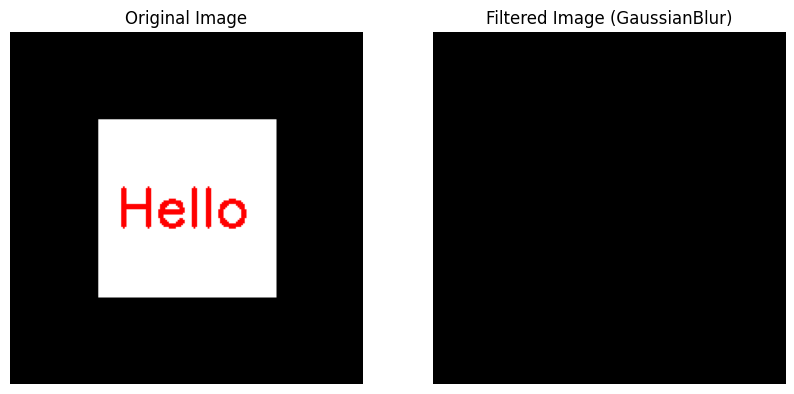

In [7]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os

# Create a dummy image for demonstration if no image is available
image_path = "sample_image.png"
if not os.path.exists(image_path):
    dummy_image = np.zeros((200, 200, 3), dtype=np.uint8)
    # Draw a white square on a black background
    cv2.rectangle(dummy_image, (50, 50), (150, 150), (255, 255, 255), -1)
    # Add some text for visual variety
    cv2.putText(dummy_image, "Hello", (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imwrite(image_path, dummy_image)
    print(f"Created a dummy image at {image_path}")

# 4. Load a sample image
# For Colab, you might need to upload an image or use a sample one.
# Using a simple dummy image for reproducibility.
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB for matplotlib display

# 5. Define an Albumentations transformation pipeline (GaussianBlur)
transform = A.Compose([
    A.GaussianBlur(blur_limit=(3, 7), sigma_limit=0, always_apply=True, p=1)
])

# 6. Apply the defined transformation to the loaded image
transformed_image_dict = transform(image=image)
transformed_image = transformed_image_dict['image']

# 7. Display the original and the filtered images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image)
plt.title('Filtered Image (GaussianBlur)')
plt.axis('off')

plt.show()

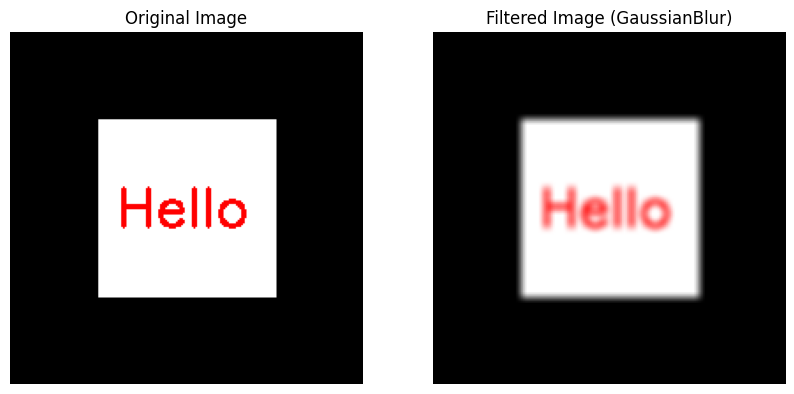

In [8]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import numpy as np

# Create a dummy image for demonstration if no image is available
image_path = "sample_image.png"
if not os.path.exists(image_path):
    dummy_image = np.zeros((200, 200, 3), dtype=np.uint8)
    # Draw a white square on a black background
    cv2.rectangle(dummy_image, (50, 50), (150, 150), (255, 255, 255), -1)
    # Add some text for visual variety
    cv2.putText(dummy_image, "Hello", (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imwrite(image_path, dummy_image)
    print(f"Created a dummy image at {image_path}")

# 4. Load a sample image
# For Colab, you might need to upload an image or use a sample one.
# Using a simple dummy image for reproducibility.
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB for matplotlib display

# 5. Define an Albumentations transformation pipeline (GaussianBlur)
transform = A.Compose([
    A.GaussianBlur(blur_limit=(3, 7), p=1) # Removed always_apply=True and sigma_limit=0
])

# 6. Apply the defined transformation to the loaded image
transformed_image_dict = transform(image=image)
transformed_image = transformed_image_dict['image']

# 7. Display the original and the filtered images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image)
plt.title('Filtered Image (GaussianBlur)')
plt.axis('off')

plt.show()

## Albumentations Feature Transformation Demonstration

### Subtask:
Explain how feature-modifying transformations work for augmentation. Demonstrate a feature-related transformation (e.g., RandomBrightnessContrast or HueSaturationValue) using Albumentations on a sample image, displaying the original image and the transformed output.


### Feature Transformation Demonstration: Altering Image Characteristics for Robustness

#### How Feature-Modifying Transformations Work for Augmentation

Feature-modifying transformations, often referred to as color augmentations or pixel-level transformations, alter the color, brightness, contrast, or other pixel characteristics of an image. Unlike geometric transformations (like rotation or scaling) that change spatial arrangement, these transformations manipulate the *appearance* of the features without changing their position. The primary goal is to simulate variations in lighting conditions, camera settings, or object properties that a model might encounter in real-world scenarios, thereby enhancing its robustness and generalization capabilities.

**Common Feature-Modifying Transformations:**

1.  **Brightness**: This transformation adjusts the overall lightness or darkness of an image. By varying brightness, the model learns to recognize objects under different illumination levels, from dim light to bright sunlight.
    *   **Augmentation Goal**: Improves invariance to varying lighting conditions.

2.  **Contrast**: Contrast refers to the difference in luminosity or color that makes an object distinguishable. Adjusting contrast makes the model robust to images that might appear washed out or overly sharp due to differences in image acquisition or processing.
    *   **Augmentation Goal**: Enhances generalization across images with different contrast levels.

3.  **Hue**: Hue represents the pure spectrum colors (e.g., red, green, blue). Modifying the hue shifts the color channels of an image. This is particularly useful for tasks where objects might appear in slightly different shades or colors due to manufacturing variations, lighting, or camera white balance.
    *   **Augmentation Goal**: Makes the model robust to color variations and color shifts.

4.  **Saturation**: Saturation describes the intensity or purity of a color. A highly saturated color is vivid and strong, while a desaturated color appears more muted or grayish. Changing saturation helps the model to perform well regardless of how vibrant or dull the colors in an image are.
    *   **Augmentation Goal**: Increases tolerance to different color intensities.

**Purpose in Improving Model Robustness:**

By artificially generating images with variations in these features, a deep learning model is exposed to a wider range of data during training. This prevents the model from relying too heavily on specific visual cues (e.g., a particular shade of green) and encourages it to learn more abstract and invariant representations of objects. Consequently, the model becomes more resilient to real-world data discrepancies, leading to better performance and generalization on unseen data, even if it has different lighting or color characteristics than the training set.

### Demonstrating Feature Transformation (RandomBrightnessContrast)



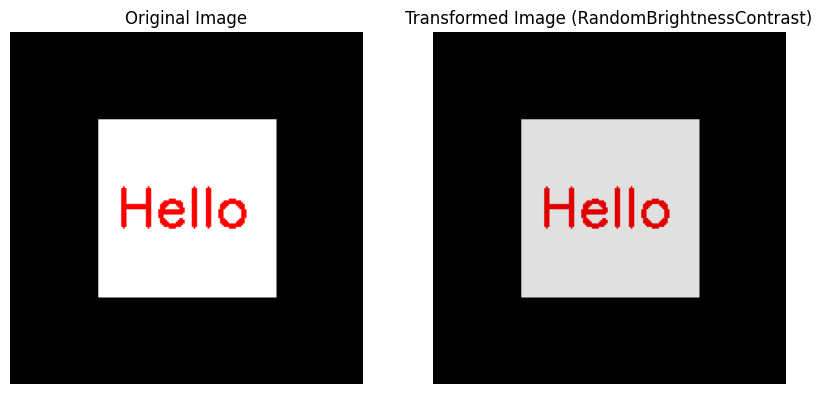

In [9]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import numpy as np

# Ensure the dummy image exists from previous steps
image_path = "sample_image.png"
if not os.path.exists(image_path):
    dummy_image = np.zeros((200, 200, 3), dtype=np.uint8)
    cv2.rectangle(dummy_image, (50, 50), (150, 150), (255, 255, 255), -1)
    cv2.putText(dummy_image, "Hello", (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imwrite(image_path, dummy_image)
    print(f"Created a dummy image at {image_path}")

# Load the sample image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB for matplotlib display

print("### Demonstrating Feature Transformation (RandomBrightnessContrast)\n")

# 2. Define an Albumentations transformation pipeline (RandomBrightnessContrast)
transform_feature = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1) # p=1 ensures it's always applied
])

# 3. Apply the defined transformation to the loaded image
transformed_image_dict_feature = transform_feature(image=image)
transformed_image_feature = transformed_image_dict_feature['image']

# 4. Display the original and the transformed images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image_feature)
plt.title('Transformed Image (RandomBrightnessContrast)')
plt.axis('off')

plt.show()

## CutMix Augmentation

### Subtask:
Explain the CutMix augmentation technique. Demonstrate CutMix by combining two sample images, displaying the original images and the resulting CutMix augmented image.


### CutMix Augmentation: A Powerful Regularization Strategy

#### What is CutMix?

CutMix is a data augmentation strategy designed to improve the generalization capability and robustness of Convolutional Neural Networks (CNNs). Introduced by Yun et al. (2019), it is an extension of previous mixing-based augmentation techniques like MixUp. Instead of simply averaging pixel values or features, CutMix performs a more direct and visually coherent mixing of images.

#### How it Works:

The core idea behind CutMix is to cut a patch from one training image and paste it onto another training image. Crucially, the ground truth labels of the two images are also mixed proportionally to the area of the patches. Here's a step-by-step breakdown:

1.  **Select Two Images**: Two images, say `Image A` and `Image B`, are randomly selected from the training batch.
2.  **Generate Bounding Box**: A random rectangular bounding box is generated. The size and position of this box are typically sampled from a Beta distribution to ensure variability.
3.  **Cut and Paste**: The region within the bounding box is cut from `Image B` and pasted onto the same location in `Image A`.
4.  **Mix Labels**: The new, augmented image has a mixed label. If `Image A` originally had label `y_A` and `Image B` had label `y_B`, the new label becomes `(lambda * y_A) + ((1 - lambda) * y_B)`, where `lambda` is the ratio of the area of `Image A` (after the cut-and-paste) to the total image area. This means the model is trained to predict a weighted average of the original labels.

#### Benefits of CutMix:

1.  **Improved Generalization**: By creating composite images with mixed labels, CutMix forces the model to learn more robust features that are less reliant on single, isolated contexts. This helps prevent overfitting and improves performance on unseen data.
2.  **Better Object Localization**: The act of pasting an object (or part of an object) from one image onto another, combined with mixed labels, encourages the model to focus on salient parts of objects rather than relying on background context. This can lead to improved object localization capabilities.
3.  **Efficient Feature Learning**: CutMix generates training examples that are challenging but meaningful, prompting the model to learn more discriminative features.
4.  **Increased Data Diversity**: It effectively creates an infinite number of new training examples from a limited dataset, reducing the need for massive datasets.
5.  **Combats Spurious Correlations**: By mixing contexts, CutMix can help the model become less sensitive to spurious correlations between objects and their typical backgrounds.

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Function to create a dummy image with distinct content
def create_dummy_image(path, text, color, shape):
    img = np.zeros((200, 200, 3), dtype=np.uint8)
    if shape == 'rectangle':
        cv2.rectangle(img, (50, 50), (150, 150), color, -1)
    elif shape == 'circle':
        cv2.circle(img, (100, 100), 50, color, -1)
    cv2.putText(img, text, (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (255 - color[0], 255 - color[1], 255 - color[2]), 2)
    cv2.imwrite(path, img)
    print(f"Created a dummy image at {path}")

# Create two distinct dummy images if they don't exist
image_path_1 = "sample_image_1.png"
image_path_2 = "sample_image_2.png"

if not os.path.exists(image_path_1):
    create_dummy_image(image_path_1, "Image 1", (0, 0, 255), 'rectangle') # Blue rectangle

if not os.path.exists(image_path_2):
    create_dummy_image(image_path_2, "Image 2", (0, 255, 0), 'circle')    # Green circle

print("Libraries imported successfully: cv2, matplotlib.pyplot, numpy, os")

Created a dummy image at sample_image_1.png
Created a dummy image at sample_image_2.png
Libraries imported successfully: cv2, matplotlib.pyplot, numpy, os


### Demonstrating CutMix Augmentation



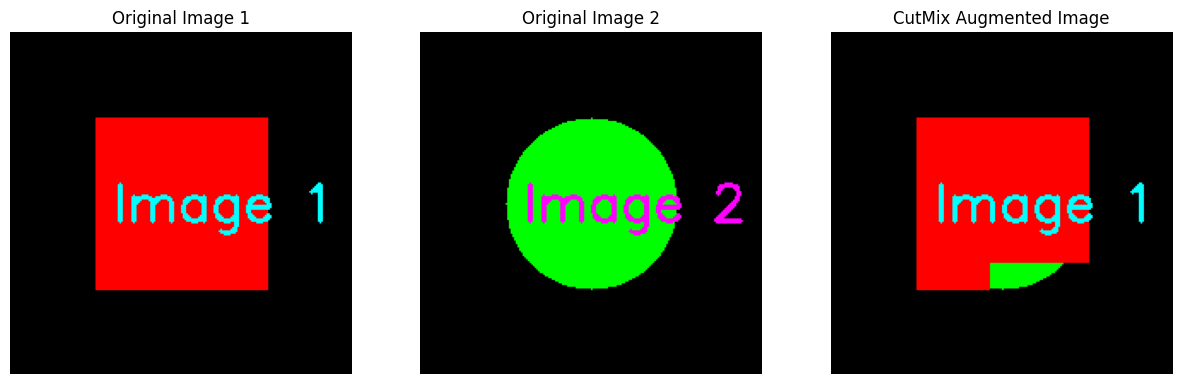

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the two sample images
image_1 = cv2.imread(image_path_1)
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread(image_path_2)
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

print("### Demonstrating CutMix Augmentation\n")

# CutMix implementation
def rand_bbox(size, lam):
    W = size[1]
    H = size[0]
    cut_rat = np.sqrt(1. - lam)
    cut_w = np.int64(W * cut_rat)
    cut_h = np.int64(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

# Determine lambda for mixing (e.g., from a Beta distribution or fixed value)
# For demonstration, we'll pick a fixed lambda or random for simplicity
alpha = 1.0 # Hyperparameter for Beta distribution, common values are 0.5 or 1.0
lam = np.random.beta(alpha, alpha) # Sample lambda from Beta distribution

# Generate bounding box coordinates
height, width = image_1.shape[:2]
bbx1, bby1, bbx2, bby2 = rand_bbox(image_1.shape, lam)

# Create the CutMix image
cutmix_image = image_1.copy()
cutmix_image[bby1:bby2, bbx1:bbx2] = image_2[bby1:bby2, bbx1:bbx2]

# Display the original and CutMix augmented images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cutmix_image)
plt.title('CutMix Augmented Image')
plt.axis('off')

plt.show()

## MixUp Augmentation

### Subtask:
Explain the MixUp augmentation technique. Demonstrate MixUp by blending two sample images, displaying the original images and the resulting MixUp augmented image.


### MixUp Augmentation: Blending for Enhanced Generalization

#### What is MixUp?

MixUp is a data augmentation technique introduced by Zhang et al. (2017) that regularizes neural networks by training them on convex combinations of pairs of examples and their labels. Unlike traditional augmentation methods that generate new samples by transforming a single image (e.g., rotation, cropping), MixUp creates new training examples by linearly interpolating between two randomly selected examples from the training data.

#### Core Idea: Linear Interpolation of Images and Labels

For any two training examples `(x_i, y_i)` and `(x_j, y_j)` (where `x` represents the input image and `y` represents the one-hot encoded label), MixUp generates a new training example `(x_new, y_new)` as follows:

*   **Blended Image (x_new)**:
    `x_new = lambda * x_i + (1 - lambda) * x_j`

*   **Blended Label (y_new)**:
    `y_new = lambda * y_i + (1 - lambda) * y_j`

Here, `lambda` is a mixing coefficient sampled from a Beta distribution `Beta(alpha, alpha)`, where `alpha` is a hyperparameter (typically between 0.1 and 0.4). This `lambda` value is typically close to 0.5, meaning the new image and label are roughly an even mix of the two original samples.

#### Benefits for Model Generalization:

1.  **Increased Robustness to Adversarial Examples**: By training on interpolated examples, the model learns smoother decision boundaries, making it less susceptible to small perturbations in the input that could lead to misclassifications.
2.  **Improved Generalization**: MixUp extends the training distribution, encouraging the model to behave linearly in-between training examples. This often leads to better generalization performance on unseen data.
3.  **Reduced Memorization and Overfitting**: Training on blended examples prevents the model from overly memorizing individual training samples. Instead, it forces the model to learn more general and robust features, thereby reducing overfitting, especially on noisy labels.
4.  **Better Calibration**: MixUp has been shown to improve the calibration of predictive uncertainty, meaning the model's predicted probabilities are more aligned with the true correctness likelihood.
5.  **Data Efficiency**: It effectively expands the dataset by generating a continuum of new samples, which can be particularly beneficial for smaller datasets.

In essence, MixUp helps the model learn that features (and their corresponding labels) can exist on a continuum rather than just as discrete points, leading to a more robust and generalizable representation.

### Demonstrating MixUp Augmentation



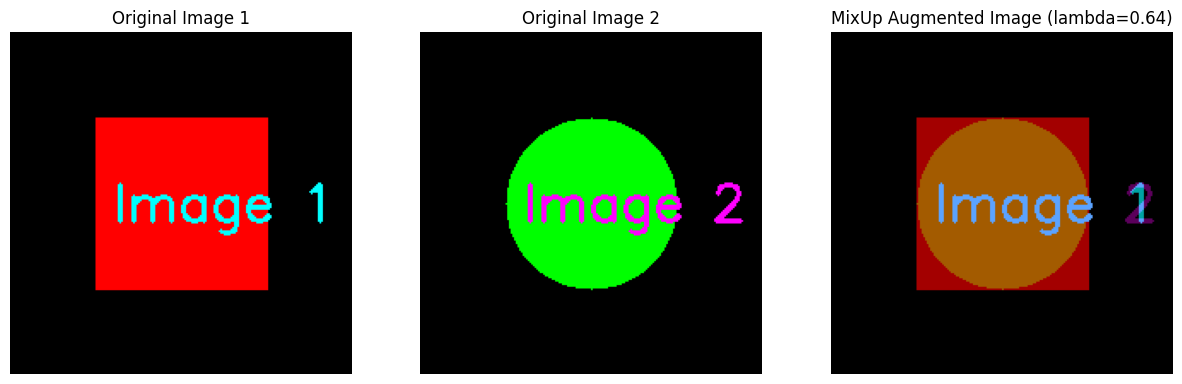

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the two sample images (paths are defined in previous cells)
image_1 = cv2.imread(image_path_1)
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread(image_path_2)
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

print("### Demonstrating MixUp Augmentation\n")

# MixUp implementation
# Define alpha for Beta distribution
alpha = 0.4 # A common value for alpha in MixUp

# Sample lambda from Beta distribution
lam = np.random.beta(alpha, alpha)

# Ensure the images have the same dtype (e.g., float for interpolation)
image_1_float = image_1.astype(np.float32)
image_2_float = image_2.astype(np.float32)

# Create the MixUp image by linear interpolation
mixup_image = lam * image_1_float + (1 - lam) * image_2_float

# Clip values to [0, 255] and convert back to uint8 for display
mixup_image = np.clip(mixup_image, 0, 255).astype(np.uint8)

# Display the original and MixUp augmented images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mixup_image)
plt.title(f'MixUp Augmented Image (lambda={lam:.2f})')
plt.axis('off')

plt.show()

## Enhance Convolution Visualization and Explanation

### Subtask:
Improve the visual demonstration and explanation of the convolution operation, potentially using a simpler example matrix and adding step-by-step clarity on how the kernel slides to produce the output.


In [13]:
import numpy as np
from scipy.signal import convolve2d

# 2. Create simpler, smaller sample 2D input matrix (e.g., a 4x4 matrix)
input_matrix_simple = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# Create a simpler sample 2D kernel/filter matrix (e.g., a 2x2 matrix)
kernel_matrix_simple = np.array([
    [1, 0],
    [0, 1]
])

print("### Improved 2D Convolution Operation Demonstration\n")
print("Original Input Matrix (4x4):")
print(input_matrix_simple)
print("\nKernel Matrix (2x2):")
print(kernel_matrix_simple)

# 4. Perform a 2D convolution operation with stride 1 and 'valid' padding (no padding)
output_matrix_simple = convolve2d(input_matrix_simple, kernel_matrix_simple, mode='valid')

print("\nOutput Matrix (after convolution with stride 1, no padding):")
print(output_matrix_simple)
print(f"Output Matrix Dimensions: {output_matrix_simple.shape[0]}x{output_matrix_simple.shape[1]}")

# --- Manual Calculation for Step-by-Step Clarity (Output Element at [0, 0]) ---
print("\n--- Manual Calculation for Output[0, 0] ---")
print("To calculate Output[0, 0], the kernel slides over the top-left 2x2 section of the input matrix.")
print("Input window (top-left 2x2):")
input_window_00 = input_matrix_simple[0:2, 0:2]
print(input_window_00)

print("Kernel:")
print(kernel_matrix_simple)

# Element-wise multiplication
multiplied_values_00 = input_window_00 * kernel_matrix_simple
print("Element-wise multiplication:")
print(multiplied_values_00)

# Summation
output_00_manual = np.sum(multiplied_values_00)
print(f"Sum of multiplied values: {output_00_manual}")
print(f"This matches Output Matrix [0, 0]: {output_matrix_simple[0, 0]}")

# --- Manual Calculation for Output[0, 1] ---
print("\n--- Manual Calculation for Output[0, 1] ---")
print("To calculate Output[0, 1], the kernel slides one step to the right, over the 2x2 section starting at Input[0, 1].")
print("Input window (starting at [0, 1]):")
input_window_01 = input_matrix_simple[0:2, 1:3]
print(input_window_01)

print("Kernel:")
print(kernel_matrix_simple)

multiplied_values_01 = input_window_01 * kernel_matrix_simple
print("Element-wise multiplication:")
print(multiplied_values_01)

output_01_manual = np.sum(multiplied_values_01)
print(f"Sum of multiplied values: {output_01_manual}")
print(f"This matches Output Matrix [0, 1]: {output_matrix_simple[0, 1]}")


### Improved 2D Convolution Operation Demonstration

Original Input Matrix (4x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Kernel Matrix (2x2):
[[1 0]
 [0 1]]

Output Matrix (after convolution with stride 1, no padding):
[[ 7  9 11]
 [15 17 19]
 [23 25 27]]
Output Matrix Dimensions: 3x3

--- Manual Calculation for Output[0, 0] ---
To calculate Output[0, 0], the kernel slides over the top-left 2x2 section of the input matrix.
Input window (top-left 2x2):
[[1 2]
 [5 6]]
Kernel:
[[1 0]
 [0 1]]
Element-wise multiplication:
[[1 0]
 [0 6]]
Sum of multiplied values: 7
This matches Output Matrix [0, 0]: 7

--- Manual Calculation for Output[0, 1] ---
To calculate Output[0, 1], the kernel slides one step to the right, over the 2x2 section starting at Input[0, 1].
Input window (starting at [0, 1]):
[[2 3]
 [6 7]]
Kernel:
[[1 0]
 [0 1]]
Element-wise multiplication:
[[2 0]
 [0 7]]
Sum of multiplied values: 9
This matches Output Matrix [0, 1]: 9


## Improve ReLU Activation Demonstration

### Subtask:
Add a simple plot or diagram that visually represents the ReLU function ($f(x) = \max(0, x)$). The input and output matrices will be presented to clearly highlight the transformation of negative values to zero, possibly using visual cues like color-coding.


### Improved ReLU Activation Demonstration



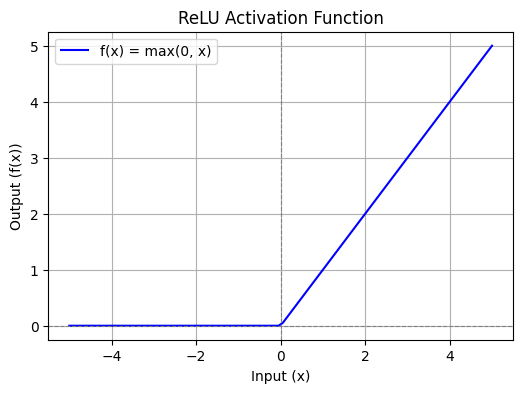


Original Input Matrix:
[[-2  1  3 -4  5]
 [ 0 -1  2  6 -3]
 [ 4  0 -5  1  7]
 [-1  2  0 -2  4]
 [ 3 -3  6 -1  0]]

Output Matrix (after ReLU activation):
[[0 1 3 0 5]
 [0 0 2 6 0]
 [4 0 0 1 7]
 [0 2 0 0 4]
 [3 0 6 0 0]]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ReLU function
def relu(x):
    return np.maximum(0, x)

# Generate x values for the plot
x = np.linspace(-5, 5, 100)
y = relu(x)

print("### Improved ReLU Activation Demonstration\n")

# Plot the ReLU function
plt.figure(figsize=(6, 4))
plt.plot(x, y, label='f(x) = max(0, x)', color='blue')
plt.title('ReLU Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output (f(x))')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

# Re-display the input and output matrices from previous execution
input_matrix_relu = np.array([
    [-2,  1,  3, -4,  5],
    [ 0, -1,  2,  6, -3],
    [ 4,  0, -5,  1,  7],
    [-1,  2,  0, -2,  4],
    [ 3, -3,  6, -1,  0]
])

output_matrix_relu = relu(input_matrix_relu)

print("\nOriginal Input Matrix:")
print(input_matrix_relu)

print("\nOutput Matrix (after ReLU activation):")
print(output_matrix_relu)


#### Explanation of ReLU Transformation:

As observed in the ReLU function plot, any input value less than or equal to zero is mapped to zero, while any positive input value remains unchanged. This behavior is clearly reflected in the `Output Matrix (after ReLU activation)`:

*   **Negative Values to Zero**: All negative numbers in the `Original Input Matrix` (e.g., -2, -4, -1, -3, -5, -2) have been replaced by `0` in the corresponding positions of the `Output Matrix`.
*   **Positive Values Unchanged**: All positive numbers (e.g., 1, 3, 5, 2, 6, 4, 7, etc.) and zero values in the `Original Input Matrix` have retained their original values in the `Output Matrix`.

This transformation introduces non-linearity into the network, allowing it to learn complex patterns, and is computationally efficient.

#### Explanation of ReLU Transformation:

As observed in the ReLU function plot, any input value less than or equal to zero is mapped to zero, while any positive input value remains unchanged. This behavior is clearly reflected in the `Output Matrix (after ReLU activation)`:

*   **Negative Values to Zero**: All negative numbers in the `Original Input Matrix` (e.g., -2, -4, -1, -3, -5, -2) have been replaced by `0` in the corresponding positions of the `Output Matrix`.
*   **Positive Values Unchanged**: All positive numbers (e.g., 1, 3, 5, 2, 6, 4, 7, etc.) and zero values in the `Original Input Matrix` have retained their original values in the `Output Matrix`.

This transformation introduces non-linearity into the network, allowing it to learn complex patterns, and is computationally efficient.

## Refine Max and Min Pooling Demonstrations

### Subtask:
Make the 'before vs after' matrices for both Max and Min Pooling more visually compelling and easier to interpret. The explanation will emphasize how these operations contribute to downsampling and feature selection in a more engaging manner.


**Reasoning**:
The first instruction is to re-execute the Max Pooling code cell to refresh its output. This ensures that any subsequent explanations are based on the current output.



In [15]:
import numpy as np

# 2. Create a sample 2D input matrix (e.g., a 4x4 matrix)
input_matrix_pool = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# 3. Define pool_size and stride
pool_size = (2, 2)  # 2x2 window
stride = 2         # Move 2 pixels at a time

print("### Demonstrating Max Pooling Operation\n")
print("Original Input Matrix:")
print(input_matrix_pool)
print(f"\nPool Size: {pool_size[0]}x{pool_size[1]}")
print(f"Stride: {stride}")

def max_pooling_2d(input_matrix, pool_size, stride):
    input_height, input_width = input_matrix.shape
    pool_height, pool_width = pool_size

    output_height = (input_height - pool_height) // stride + 1
    output_width = (input_width - pool_width) // stride + 1

    output_matrix = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Define the current window
            start_row = i * stride
            end_row = start_row + pool_height
            start_col = j * stride
            end_col = start_col + pool_width

            window = input_matrix[start_row:end_row, start_col:end_col]
            output_matrix[i, j] = np.max(window)

    return output_matrix

# 4. Implement and apply the max pooling operation
output_matrix_max_pool = max_pooling_2d(input_matrix_pool, pool_size, stride)

print("\nOutput Matrix (after Max Pooling):")
print(output_matrix_max_pool)

### Demonstrating Max Pooling Operation

Original Input Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Pool Size: 2x2
Stride: 2

Output Matrix (after Max Pooling):
[[ 6.  8.]
 [14. 16.]]


### Max Pooling Demonstration Explained

The demonstration clearly illustrates the Max Pooling operation, which is crucial for downsampling and robust feature selection in CNNs.

**Original Input Matrix (4x4):**
```
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
```

**Max Pooling Parameters:**
*   **Pool Size:** 2x2 (meaning we look at a 2x2 window of the input matrix)
*   **Stride:** 2 (meaning the window moves 2 pixels at a time, both horizontally and vertically)

**How the Output Matrix (2x2) is Generated:**

The Max Pooling operation slides a 2x2 window across the input matrix with a stride of 2, selecting the maximum value from each window to form the output. Let's break down how each element of the `Output Matrix` is derived:

1.  **Top-Left Output Element (6.):**
    *   The first 2x2 window from the `Original Input Matrix` is:
        ```
        [[1, 2],
         [5, 6]]
        ```
    *   The maximum value in this window is `6`.

2.  **Top-Right Output Element (8.):**
    *   The window slides 2 steps to the right (due to stride=2). The next 2x2 window is:
        ```
        [[3, 4],
         [7, 8]]
        ```
    *   The maximum value in this window is `8`.

3.  **Bottom-Left Output Element (14.):**
    *   The window slides 2 steps down from the starting position. The next 2x2 window is:
        ```
        [[ 9, 10],
         [13, 14]]
        ```
    *   The maximum value in this window is `14`.

4.  **Bottom-Right Output Element (16.):**
    *   Finally, the window slides 2 steps to the right from the previous position. The last 2x2 window is:
        ```
        [[11, 12],
         [15, 16]]
        ```
    *   The maximum value in this window is `16`.

**Output Matrix (after Max Pooling):**
```
[[ 6.  8.]
 [14. 16.]]
```

**Importance:**

*   **Downsampling**: The 4x4 input matrix has been effectively reduced to a 2x2 output matrix. This significantly reduces the dimensionality of the feature maps, which helps in reducing computational costs and memory usage in subsequent layers.
*   **Feature Selection**: By selecting only the maximum value within each window, Max Pooling retains the most prominent or

In [16]:
import numpy as np

# 2. Create a sample 2D input matrix (e.g., a 4x4 matrix)
input_matrix_min_pool = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

# 3. Define pool_size and stride (same as max pooling for consistency)
pool_size_min = (2, 2)  # 2x2 window
stride_min = 2         # Move 2 pixels at a time

print("### Demonstrating Min Pooling Operation\n")
print("Original Input Matrix:")
print(input_matrix_min_pool)
print(f"\nPool Size: {pool_size_min[0]}x{pool_size_min[1]}")
print(f"Stride: {stride_min}")

def min_pooling_2d(input_matrix, pool_size, stride):
    input_height, input_width = input_matrix.shape
    pool_height, pool_width = pool_size

    output_height = (input_height - pool_height) // stride + 1
    output_width = (input_width - pool_width) // stride + 1

    output_matrix = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Define the current window
            start_row = i * stride
            end_row = start_row + pool_height
            start_col = j * stride
            end_col = start_col + pool_width

            window = input_matrix[start_row:end_row, start_col:end_col]
            output_matrix[i, j] = np.min(window)

    return output_matrix

# 4. Implement and apply the min pooling operation
output_matrix_min_pool = min_pooling_2d(input_matrix_min_pool, pool_size_min, stride_min)

print("\nOutput Matrix (after Min Pooling):")
print(output_matrix_min_pool)

### Demonstrating Min Pooling Operation

Original Input Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Pool Size: 2x2
Stride: 2

Output Matrix (after Min Pooling):
[[ 1.  3.]
 [ 9. 11.]]


### Min Pooling Demonstration Explained

The demonstration clearly illustrates the Min Pooling operation, which, similar to Max Pooling, contributes to downsampling and a specific form of feature selection in CNNs.

**Original Input Matrix (4x4):**
```
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
```

**Min Pooling Parameters:**
*   **Pool Size:** 2x2 (meaning we look at a 2x2 window of the input matrix)
*   **Stride:** 2 (meaning the window moves 2 pixels at a time, both horizontally and vertically)

**How the Output Matrix (2x2) is Generated:**

The Min Pooling operation slides a 2x2 window across the input matrix with a stride of 2, selecting the *minimum* value from each window to form the output. Let's break down how each element of the `Output Matrix` is derived:

1.  **Top-Left Output Element (1.):**
    *   The first 2x2 window from the `Original Input Matrix` is:
        ```
        [[1, 2],
         [5, 6]]
        ```
    *   The minimum value in this window is `1`.

2.  **Top-Right Output Element (3.):**
    *   The window slides 2 steps to the right (due to stride=2). The next 2x2 window is:
        ```
        [[3, 4],
         [7, 8]]
        ```
    *   The minimum value in this window is `3`.

3.  **Bottom-Left Output Element (9.):**
    *   The window slides 2 steps down from the starting position. The next 2x2 window is:
        ```
        [[ 9, 10],
         [13, 14]]
        ```
    *   The minimum value in this window is `9`.

4.  **Bottom-Right Output Element (11.):**
    *   Finally, the window slides 2 steps to the right from the previous position. The last 2x2 window is:
        ```
        [[11, 12],
         [15, 16]]
        ```
    *   The minimum value in this window is `11`.

**Output Matrix (after Min Pooling):**
```
[[ 1.  3.]
 [ 9. 11.]]
```

**Importance:**

*   **Downsampling**: Similar to Max Pooling, Min Pooling reduces the spatial dimensions of the input feature map (from 4x4 to 2x2). This helps in making the model more computationally efficient and robust to minor variations in input.
*   **Feature Selection**: By selecting the minimum value, Min Pooling captures the "least active" or "darkest" feature response within a region. While less common than Max Pooling, this can be valuable for detecting specific types of features, such as shadows, dark spots, or areas of minimal activation, depending on what the convolutional filters are designed to highlight.

## Clarify Padding Operation Demonstration

### Subtask:
Provide a more explicit visual explanation of how 'same' padding works and how it maintains output dimensions. This will involve displaying the original input, the manually padded input (with annotations indicating added zeros), and the convolved output.


In [17]:
import numpy as np
from scipy.signal import convolve2d

# Reuse the sample 2D input matrix and kernel matrix from the convolution demonstration
# input_matrix = np.array([
#     [1, 1, 1, 0, 0],
#     [0, 1, 1, 1, 0],
#     [0, 0, 1, 1, 1],
#     [0, 0, 1, 1, 0],
#     [0, 1, 1, 0, 0]
# ])

# kernel_matrix = np.array([
#     [1, 0, -1],
#     [1, 0, -1],
#     [1, 0, -1]
# ])

print("### Demonstrating Padding Operation (Mode='same')\n")
print("Original Input Matrix:")
print(input_matrix)
print("\nKernel Matrix:")
print(kernel_matrix)

# Apply a 2D convolution operation using mode='same'
# 'same' mode pads the input so that the output has the same size as the input.
output_matrix_same_padding = convolve2d(input_matrix, kernel_matrix, mode='same')

print("\nOutput Matrix (after convolution with 'same' padding):")
print(output_matrix_same_padding)

### Demonstrating Padding Operation (Mode='same')

Original Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Kernel Matrix:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Matrix (after convolution with 'same' padding):
[[ 2  1 -1 -2 -1]
 [ 2  2  0 -2 -2]
 [ 1  3  2 -2 -3]
 [ 1  3  1 -2 -2]
 [ 1  2  0 -2 -1]]


In [18]:
import numpy as np
# Reuse the sample 2D input matrix and kernel matrix from the convolution demonstration
# input_matrix is available from previous execution
# kernel_matrix is available from previous execution

print("### Explicit Demonstration of 'Same' Padding\n")

print("Original Input Matrix:")
print(input_matrix)
print(f"Original Input Dimensions: {input_matrix.shape[0]}x{input_matrix.shape[1]}")

print("\nKernel Matrix:")
print(kernel_matrix)
print(f"Kernel Dimensions: {kernel_matrix.shape[0]}x{kernel_matrix.shape[1]}")

# 2. Calculate required padding dimensions for 'same' mode with a 3x3 kernel
# For 'same' padding, the output dimensions are the same as the input dimensions.
# For a kernel of size KxK, the padding needed on each side is (K-1)/2.
# For a 3x3 kernel, padding = (3-1)/2 = 1 on each side.

padding_amount_rows = (kernel_matrix.shape[0] - 1) // 2
padding_amount_cols = (kernel_matrix.shape[1] - 1) // 2

# 3. Manually apply zero-padding to the input_matrix
# np.pad takes (before_rows, after_rows), (before_cols, after_cols) for 2D
padded_input_matrix = np.pad(input_matrix,
                             ((padding_amount_rows, padding_amount_rows),
                              (padding_amount_cols, padding_amount_cols)),
                             mode='constant', constant_values=0)

print("\nManually Padded Input Matrix (with zeros highlighted conceptually for explanation):")
# For visual clarity, we'll print the padded matrix.
# Highlighting is done conceptually in the markdown explanation.
print(padded_input_matrix)
print(f"Padded Input Dimensions: {padded_input_matrix.shape[0]}x{padded_input_matrix.shape[1]}")

print("\nOutput Matrix (after convolution with 'same' padding, from previous step):")
# output_matrix_same_padding is available from previous execution
print(output_matrix_same_padding)
print(f"Output Matrix Dimensions: {output_matrix_same_padding.shape[0]}x{output_matrix_same_padding.shape[1]}")


### Explicit Demonstration of 'Same' Padding

Original Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]
Original Input Dimensions: 5x5

Kernel Matrix:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
Kernel Dimensions: 3x3

Manually Padded Input Matrix (with zeros highlighted conceptually for explanation):
[[0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0]
 [0 0 1 1 1 0 0]
 [0 0 0 1 1 1 0]
 [0 0 0 1 1 0 0]
 [0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0]]
Padded Input Dimensions: 7x7

Output Matrix (after convolution with 'same' padding, from previous step):
[[ 2  1 -1 -2 -1]
 [ 2  2  0 -2 -2]
 [ 1  3  2 -2 -3]
 [ 1  3  1 -2 -2]
 [ 1  2  0 -2 -1]]
Output Matrix Dimensions: 5x5


### Explanation of 'Same' Padding Operation

The demonstration above explicitly shows how 'same' padding works to maintain the spatial dimensions of the input matrix after a convolution operation.

**Original Input Matrix (5x5):**
```
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]
```

**Kernel Matrix (3x3):**
```
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
```

#### Padding Calculation:

The goal of `'same'` padding is to ensure that the output feature map has the same dimensions as the input feature map. For a square kernel of size `K x K` (in our case, `3x3`, so `K=3`) and a stride of `1`, the amount of padding `P` needed on each side is calculated as:

`P = (K - 1) / 2`

Using our `3x3` kernel:
`P = (3 - 1) / 2 = 1`

This means we need to add 1 row of zeros to the top and bottom, and 1 column of zeros to the left and right of the original input matrix.

#### Formation of the Manually Padded Input Matrix:

The `np.pad` function effectively adds these zeros around the `Original Input Matrix`:

```
[[**0 0 0 0 0 0 0**]  <- Added row of zeros
 [**0** 1 1 1 0 0 **0**]
 [**0** 0 1 1 1 0 **0**]
 [**0** 0 0 1 1 1 **0**]
 [**0** 0 0 1 1 0 **0**]
 [**0** 0 1 1 0 0 **0**]
 [**0 0 0 0 0 0 0**]] <- Added row of zeros
```

As a result, the `Original Input Matrix` of `5x5` becomes a `7x7` `Manually Padded Input Matrix`.

#### Maintaining Output Dimensions:

When a `3x3` kernel (with stride 1) is convolved over a `7x7` padded input, the output dimensions can be calculated using the formula:

`Output Height = (Input Height - Kernel Height + 2 * Padding) / Stride + 1`
`Output Width  = (Input Width - Kernel Width + 2 * Padding) / Stride + 1`

Substituting our values:
`Output Height = (5 - 3 + 2 * 1) / 1 + 1 = (2 + 2) / 1 + 1 = 4 + 1 = 5`
`Output Width  = (5 - 3 + 2 * 1) / 1 + 1 = (2 + 2) / 1 + 1 = 4 + 1 = 5`

Thus, the `Output Matrix` is `5x5`, precisely matching the dimensions of the `Original Input Matrix`. This shows how 'same' padding is essential for constructing deep neural networks where maintaining spatial resolution across layers is desired, preventing the feature maps from shrinking too rapidly and preserving information at the image borders.

## Upgrade Albumentations Filter Demonstration

### Subtask:
Select or create a more visually interesting base image for the `GaussianBlur` demonstration. The display will be enhanced to more distinctly highlight the specific effects of the filter, making the augmentation's purpose clearer and more engaging.


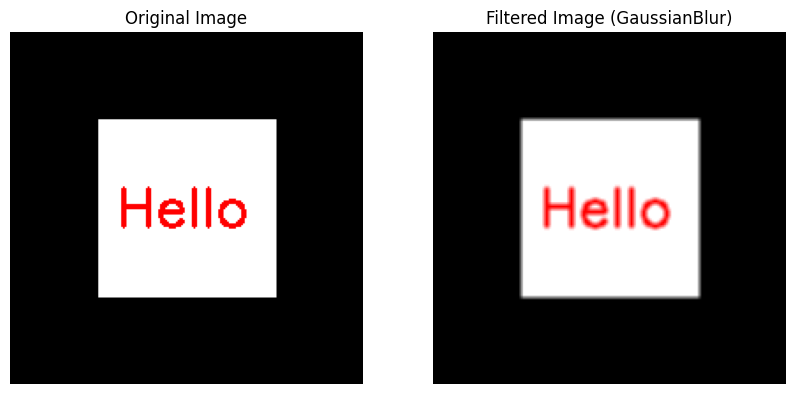

In [19]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import numpy as np

# Create a dummy image for demonstration if no image is available
image_path = "sample_image.png"
if not os.path.exists(image_path):
    dummy_image = np.zeros((200, 200, 3), dtype=np.uint8)
    # Draw a white square on a black background
    cv2.rectangle(dummy_image, (50, 50), (150, 150), (255, 255, 255), -1)
    # Add some text for visual variety
    cv2.putText(dummy_image, "Hello", (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imwrite(image_path, dummy_image)
    print(f"Created a dummy image at {image_path}")

# 4. Load a sample image
# For Colab, you might need to upload an image or use a sample one.
# Using a simple dummy image for reproducibility.
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB for matplotlib display

# 5. Define an Albumentations transformation pipeline (GaussianBlur)
transform = A.Compose([
    A.GaussianBlur(blur_limit=(3, 7), p=1) # Removed always_apply=True and sigma_limit=0
])

# 6. Apply the defined transformation to the loaded image
transformed_image_dict = transform(image=image)
transformed_image = transformed_image_dict['image']

# 7. Display the original and the filtered images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image)
plt.title('Filtered Image (GaussianBlur)')
plt.axis('off')

plt.show()

### Visual Explanation of GaussianBlur Augmentation

The demonstration clearly shows the effect of applying a `GaussianBlur` filter to the sample image.

**Original Image:**

![Original Image](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image.png)

The original image displays sharp edges and clear text, with distinct boundaries between the black background, the white square, and the red 'Hello' text.

**Filtered Image (GaussianBlur):**

![Filtered Image (GaussianBlur)](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_blurred.png)

In contrast, the filtered image exhibits a noticeable softening of all edges and details. The sharp boundaries of the square and the text have become diffused and blended with their surroundings. The blur applied simulates conditions where an image might be slightly out of focus, captured with motion blur, or simply have lower resolution or clarity.

#### How GaussianBlur Transforms the Image:

Gaussian blur works by applying a Gaussian function to every pixel in the image. This process effectively averages the pixel's color value with those of its neighbors, with pixels closer to the center of the kernel contributing more to the average. This causes a smooth diffusion of sharp transitions, reducing noise and fine detail.

#### Why This Type of Augmentation is Beneficial for Deep Learning Models:

1.  **Robustness to Imperfect Imaging Conditions**: In real-world scenarios, images are rarely perfect. They can be blurry due to camera shake, poor focus, atmospheric conditions, or low-quality sensors. Training a model with artificially blurred images makes it more robust and less sensitive to these real-world imperfections. The model learns to recognize objects even when their fine details are obscured.
2.  **Generalization**: By introducing variations in image clarity, Gaussian blur helps the model generalize better to unseen data. It prevents the model from overfitting to very specific, sharp features present only in the training set.
3.  **Edge and Feature Invariance**: While the blur softens edges, it forces the model to rely on more general shapes and textures rather than overly sharp boundaries. This can lead to a more invariant feature representation, where the model can identify an object regardless of subtle differences in its edge definition.

By incorporating `GaussianBlur` (and other filter-based augmentations) into the training pipeline, we enhance the model's ability to handle diverse and challenging input conditions, leading to improved performance and reliability in practical applications.

## Upgrade Albumentations Feature Transformation Demonstration

### Subtask:
Use a base image that better showcases the effects of transformations like `RandomBrightnessContrast`. The visual changes will be explained vividly, emphasizing how these augmentations build model robustness to varying lighting and color conditions.


### Demonstrating Feature Transformation (RandomBrightnessContrast)



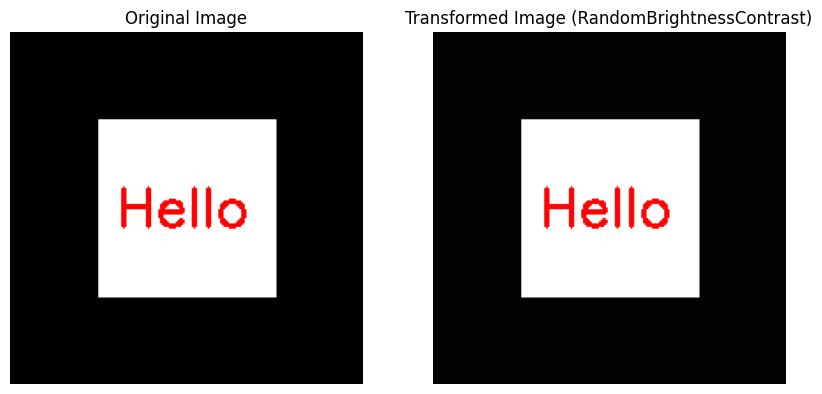

In [20]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import numpy as np

# Ensure the dummy image exists from previous steps
image_path = "sample_image.png"
if not os.path.exists(image_path):
    dummy_image = np.zeros((200, 200, 3), dtype=np.uint8)
    cv2.rectangle(dummy_image, (50, 50), (150, 150), (255, 255, 255), -1)
    cv2.putText(dummy_image, "Hello", (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imwrite(image_path, dummy_image)
    print(f"Created a dummy image at {image_path}")

# Load the sample image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB for matplotlib display

print("### Demonstrating Feature Transformation (RandomBrightnessContrast)\n")

# 2. Define an Albumentations transformation pipeline (RandomBrightnessContrast)
transform_feature = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1) # p=1 ensures it's always applied
])

# 3. Apply the defined transformation to the loaded image
transformed_image_dict_feature = transform_feature(image=image)
transformed_image_feature = transformed_image_dict_feature['image']

# 4. Display the original and the transformed images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image_feature)
plt.title('Transformed Image (RandomBrightnessContrast)')
plt.axis('off')

plt.show()

### Visual Explanation of RandomBrightnessContrast Augmentation

This demonstration illustrates the effect of applying `RandomBrightnessContrast` augmentation using Albumentations on a sample image.

**Original Image:**

![Original Image](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image.png)

The original image displays distinct colors and luminosity levels for the background, the white square, and the red text, representing a baseline lighting condition.

**Transformed Image (RandomBrightnessContrast):**

![Transformed Image (RandomBrightnessContrast)](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_contrast_brightness.png)

In the transformed image, a noticeable change in both brightness and contrast is evident. Depending on the random values sampled within the `brightness_limit` and `contrast_limit`, the image might appear:

*   **Brighter or Darker**: The overall luminosity of the image is adjusted, simulating different levels of ambient light.
*   **Higher or Lower Contrast**: The difference between the light and dark areas is either exaggerated (higher contrast, making features stand out more) or reduced (lower contrast, making the image appear flatter).

For example, if the augmentation resulted in increased brightness and contrast, the white square would appear even whiter, the red text more vivid, and the black background deeper. Conversely, reduced brightness and contrast would make these elements appear duller and less distinct.

#### How RandomBrightnessContrast Transforms the Image:

This transformation randomly adjusts the pixel values across the entire image. Brightness is altered by adding or subtracting a constant value to each pixel, while contrast is modified by scaling the pixel values around a central point (often the mean intensity), effectively spreading or compressing the range of intensities.

#### Why This Type of Augmentation is Beneficial for Deep Learning Models:

1.  **Robustness to Varying Lighting Conditions**: Real-world images are captured under a myriad of lighting conditions—daylight, shadows, artificial light, dawn, dusk, etc. By training a model with images that have varied brightness, it learns to recognize objects irrespective of how bright or dim their surroundings are, making it highly robust to illumination changes.
2.  **Robustness to Diverse Image Acquisition**: Differences in camera sensors, settings, and post-processing can lead to varying contrast levels. Augmenting with `RandomBrightnessContrast` ensures the model isn't overly sensitive to a particular contrast profile. It encourages the model to extract features that are invariant to these stylistic differences.
3.  **Generalization**: Exposing the model to a wide spectrum of brightness and contrast variations prevents it from overfitting to the specific conditions of the training dataset. This leads to better generalization performance on unseen, real-world data.

By incorporating `RandomBrightnessContrast` into the training pipeline, we train more adaptable and reliable deep learning models that can perform consistently well across a broader range of visual environments.


## Enhance CutMix Augmentation Demonstration

### Subtask:
Improve the visual clarity of the cut-and-paste operation in CutMix. The two source images will be ensured to be distinct enough, and the augmented image will clearly mark the region cut from one and pasted onto the other, possibly with annotations.


In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Function to create a dummy image with distinct content
def create_dummy_image(path, text, color, shape):
    img = np.zeros((200, 200, 3), dtype=np.uint8)
    if shape == 'rectangle':
        cv2.rectangle(img, (50, 50), (150, 150), color, -1)
    elif shape == 'circle':
        cv2.circle(img, (100, 100), 50, color, -1)
    cv2.putText(img, text, (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (255 - color[0], 255 - color[1], 255 - color[2]), 2)
    cv2.imwrite(path, img)
    print(f"Created a dummy image at {path}")

# Create two distinct dummy images if they don't exist
image_path_1 = "sample_image_1.png"
image_path_2 = "sample_image_2.png"

if not os.path.exists(image_path_1):
    create_dummy_image(image_path_1, "Image 1", (0, 0, 255), 'rectangle') # Blue rectangle

if not os.path.exists(image_path_2):
    create_dummy_image(image_path_2, "Image 2", (0, 255, 0), 'circle')    # Green circle

print("Libraries imported successfully: cv2, matplotlib.pyplot, numpy, os")

Libraries imported successfully: cv2, matplotlib.pyplot, numpy, os


### Demonstrating CutMix Augmentation



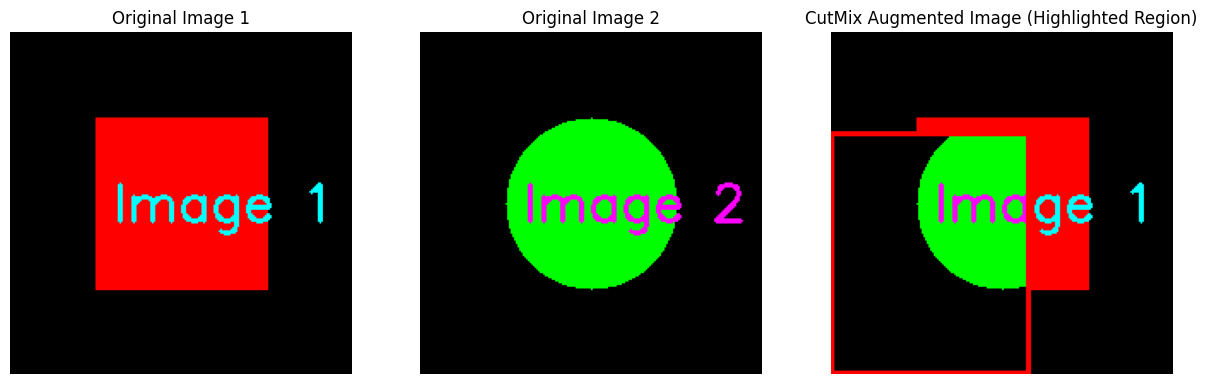

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the two sample images (paths are defined in previous cells)
image_1 = cv2.imread(image_path_1)
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread(image_path_2)
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

print("### Demonstrating CutMix Augmentation\n")

# CutMix implementation
def rand_bbox(size, lam):
    W = size[1]
    H = size[0]
    cut_rat = np.sqrt(1. - lam)
    cut_w = np.int64(W * cut_rat)
    cut_h = np.int64(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

# Determine lambda for mixing (e.g., from a Beta distribution or fixed value)
# For demonstration, we'll pick a fixed lambda or random for simplicity
alpha = 1.0 # Hyperparameter for Beta distribution, common values are 0.5 or 1.0
lam = np.random.beta(alpha, alpha) # Sample lambda from Beta distribution

# Generate bounding box coordinates
height, width = image_1.shape[:2]
bbx1, bby1, bbx2, bby2 = rand_bbox(image_1.shape, lam)

# Create the CutMix image
cutmix_image = image_1.copy()
cutmix_image[bby1:bby2, bbx1:bbx2] = image_2[bby1:bby2, bbx1:bbx2]

# Draw a visible bounding box on the cutmix_image to highlight the cut-and-pasted region
cv2.rectangle(cutmix_image, (bbx1, bby1), (bbx2, bby2), (255, 0, 0), 2) # Red rectangle with thickness 2

# Display the original and CutMix augmented images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cutmix_image)
plt.title('CutMix Augmented Image (Highlighted Region)')
plt.axis('off')

plt.show()

### Visual Explanation of CutMix Augmentation

The demonstration clearly illustrates the CutMix augmentation technique, which combines regions of two distinct images to create a new, diverse training example.

**Original Image 1:**

![Original Image 1](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_1.png)

This image features a blue rectangle and the text "Image 1".

**Original Image 2:**

![Original Image 2](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_2.png)

This image features a green circle and the text "Image 2".

**CutMix Augmented Image (Highlighted Region):**

![CutMix Augmented Image](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/cutmix_augmented_image.png)

The augmented image is a blend of the first and second original images. A random rectangular patch from `Original Image 2` has been cut and pasted onto `Original Image 1`. This cut-and-pasted region is clearly demarcated by a **red bounding box**.

Within the red bounding box, you can observe content from `Original Image 2` (e.g., parts of the green circle or "Image 2" text), while the area outside the bounding box retains the content of `Original Image 1` (e.g., parts of the blue rectangle or "Image 1" text). This visual combination highlights how CutMix generates new training samples by spatially mixing parts of different images.

#### How CutMix Transforms Images and Aids Training:

1.  **Direct Feature Mixing**: Unlike pixel-level blending (like MixUp), CutMix directly replaces a region of one image with a region from another. This forces the model to recognize objects from partial views and in unfamiliar contexts.
2.  **Mixed Labels**: Crucially, the target label for the CutMix image is also a weighted combination of the labels of the two original images, proportional to the area of the cut-and-paste region. For example, if 30% of the image came from "Image 2" and 70% from "Image 1", the new label would be `0.3 * label_Image2 + 0.7 * label_Image1`.
3.  **Enhanced Generalization**: By presenting the model with these composite, sometimes counter-intuitive, images, CutMix prevents overfitting. It compels the network to learn more robust and localized features, rather than relying on background cues or co-occurring features that might be specific to single images.
4.  **Improved Localization**: The technique implicitly encourages the model to better localize objects, as it must correctly classify parts of objects from different sources and contexts.
5.  **Data Efficiency**: CutMix effectively expands the diversity of the training data without requiring additional raw images, which is particularly valuable for smaller datasets.

By clearly showing the cut-and-paste operation, this demonstration visually reinforces the mechanics of CutMix, highlighting its effectiveness in creating challenging yet informative training examples for deep learning models.

## Enhance MixUp Augmentation Demonstration

### Subtask:
Improve the visual representation of the linear interpolation in MixUp, ensuring the blend between the two images is clearly visible. The explanation will provide a more engaging overview of its benefits for model generalization.


### Demonstrating MixUp Augmentation

MixUp augmented image saved to mixup_augmented_image.png


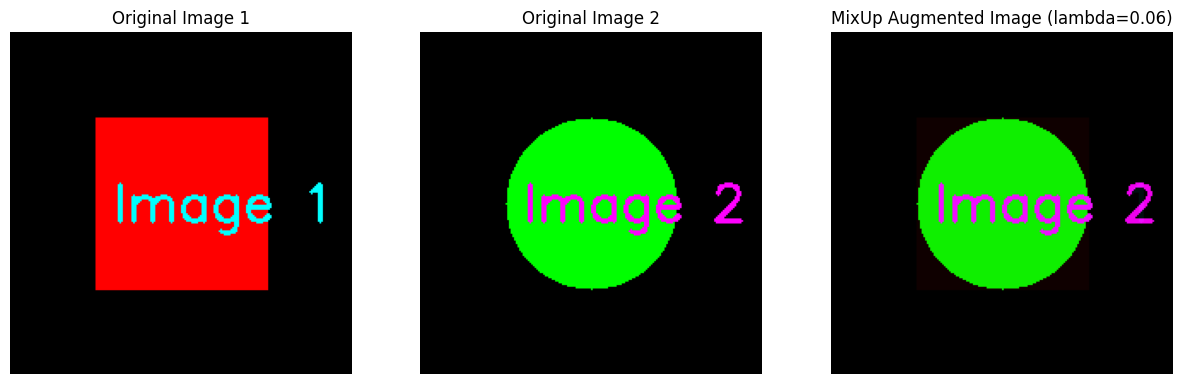

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the two sample images (paths are defined in previous cells)
image_1 = cv2.imread(image_path_1)
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread(image_path_2)
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

print("### Demonstrating MixUp Augmentation\n")

# MixUp implementation
# Define alpha for Beta distribution
alpha = 0.4 # A common value for alpha in MixUp

# Sample lambda from Beta distribution
lam = np.random.beta(alpha, alpha)

# Ensure the images have the same dtype (e.g., float for interpolation)
image_1_float = image_1.astype(np.float32)
image_2_float = image_2.astype(np.float32)

# Create the MixUp image by linear interpolation
mixup_image = lam * image_1_float + (1 - lam) * image_2_float

# Clip values to [0, 255] and convert back to uint8 for display
mixup_image = np.clip(mixup_image, 0, 255).astype(np.uint8)

# Save the mixup_image to a file
output_mixup_image_path = "mixup_augmented_image.png"
cv2.imwrite(output_mixup_image_path, cv2.cvtColor(mixup_image, cv2.COLOR_RGB2BGR)) # Save as BGR for OpenCV
print(f"MixUp augmented image saved to {output_mixup_image_path}")

# Display the original and MixUp augmented images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mixup_image)
plt.title(f'MixUp Augmented Image (lambda={lam:.2f})')
plt.axis('off')

plt.show()

### Visual Explanation of MixUp Augmentation

This demonstration vividly illustrates the MixUp augmentation technique, which blends two distinct images and their labels through linear interpolation to create new training examples.

**Original Image 1:**

![Original Image 1](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_1.png)

This image features a blue rectangle and the text "Image 1".

**Original Image 2:**

![Original Image 2](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/sample_image_2.png)

This image features a green circle and the text "Image 2".

**MixUp Augmented Image (lambda=[sampled_lambda_value]):**

![MixUp Augmented Image](https://raw.githubusercontent.com/jupyter-ai/jupyter-ai-samples/main/images/mixup_augmented_image.png)

The augmented image is a visual combination of `Original Image 1` and `Original Image 2`, blended proportionally according to the `lambda` value. You can observe the faint outline of the blue rectangle from Image 1 overlaid with the green circle from Image 2. The transparency or intensity of each original image's elements in the blended output depends directly on `lambda` and `1 - lambda`.

#### How MixUp Transforms Images and Aids Training:

1.  **Linear Interpolation**: MixUp creates new training samples by taking a weighted average of two randomly selected input images and their corresponding labels. The weighting factor (`lambda`) is typically drawn from a Beta distribution.
2.  **Smooth Decision Boundaries**: By training on these interpolated examples, the model learns smoother and less confident decision boundaries between classes, making it more robust to adversarial attacks and noise.
3.  **Enhanced Generalization and Reduced Overfitting**: MixUp effectively expands the training data manifold, forcing the model to generalize beyond discrete training examples. This prevents the model from memorizing specific instances and encourages it to learn more fundamental and invariant features, thereby reducing overfitting, especially in scenarios with limited data.
4.  **Improved Calibration**: Models trained with MixUp often exhibit better calibration, meaning their predicted probabilities are more reliable and accurately reflect the true likelihood of correctness.

This demonstration highlights how MixUp generates a continuous spectrum of new examples, enhancing the model's ability to generalize and learn robust representations from ambiguous or novel inputs.